In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.dates as mdates
from pmdarima.arima import auto_arima
import pmdarima as pm
import os, random
import warnings
warnings.filterwarnings('ignore')
import csv
import gc


# ------------------ Fix Random Seeds ------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [2]:
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

In [3]:
# Keep Month as string for submission
month_col = test_df["Month"].copy()

train_df["Month"] = pd.to_datetime(train_df["Month"], format="%d-%m-%Y")
test_df["Month"]  = pd.to_datetime(test_df["Month"],  format="%d-%m-%Y")

y = train_df["Avg_sunspot_count"].values.astype(np.float32)

In [4]:
train_df.head()

,Month,Avg_sunspot_count
0,1749-01-01,97
1,1749-01-02,104
2,1749-01-03,117
3,1749-01-04,93
4,1749-01-05,142


In [5]:
missing_values = train_df.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 Month                0
Avg_sunspot_count    0
dtype: int64


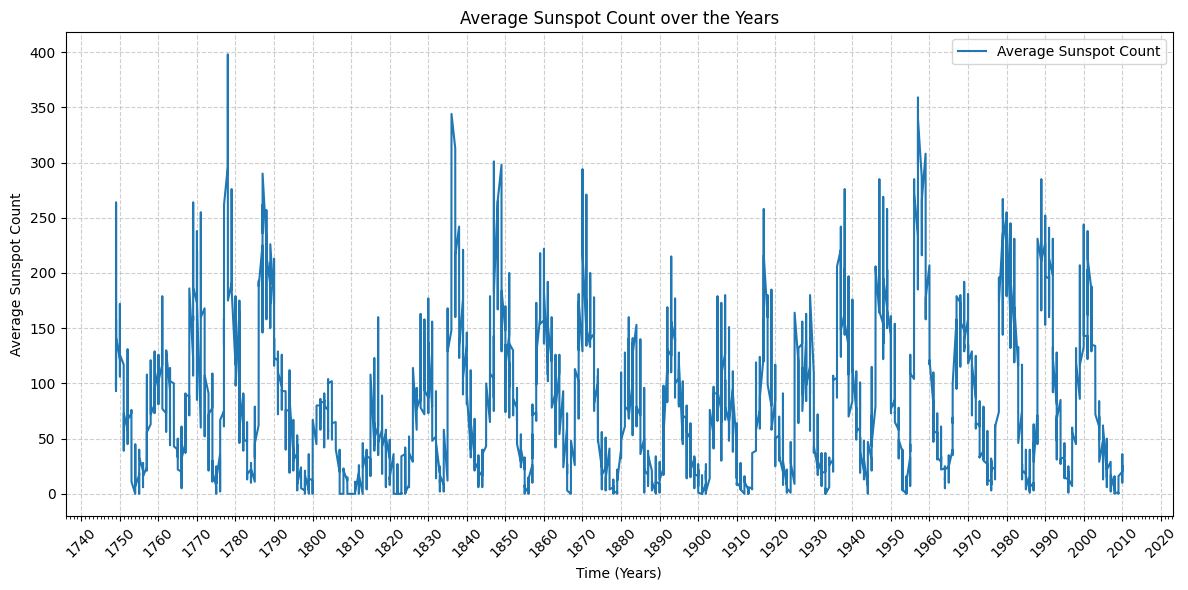

In [6]:
def plot_series(series, start=None, end=None, label=None):
    plt.figure(figsize=(12, 6))
    plt.plot(series.index[start:end], series[start:end], label=label)

    plt.xlabel("Time (Years)")
    plt.ylabel("Average Sunspot Count")
    plt.title("Average Sunspot Count over the Years")
    # Format x-axis as years
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator(base=10))   # every 10 years
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.YearLocator())          # yearly minor ticks

    plt.xticks(rotation=45)
    if label:
        plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# Use the datetime index
train_df = train_df.set_index("Month")
plot_series(train_df['Avg_sunspot_count'], label="Average Sunspot Count")

Inference: This graph indicates seasonal pattern and the trend of the Average Sunspot count over the years.

In [7]:
# Extract time and values
time_step = train_df.index
sunspots = train_df["Avg_sunspot_count"].values


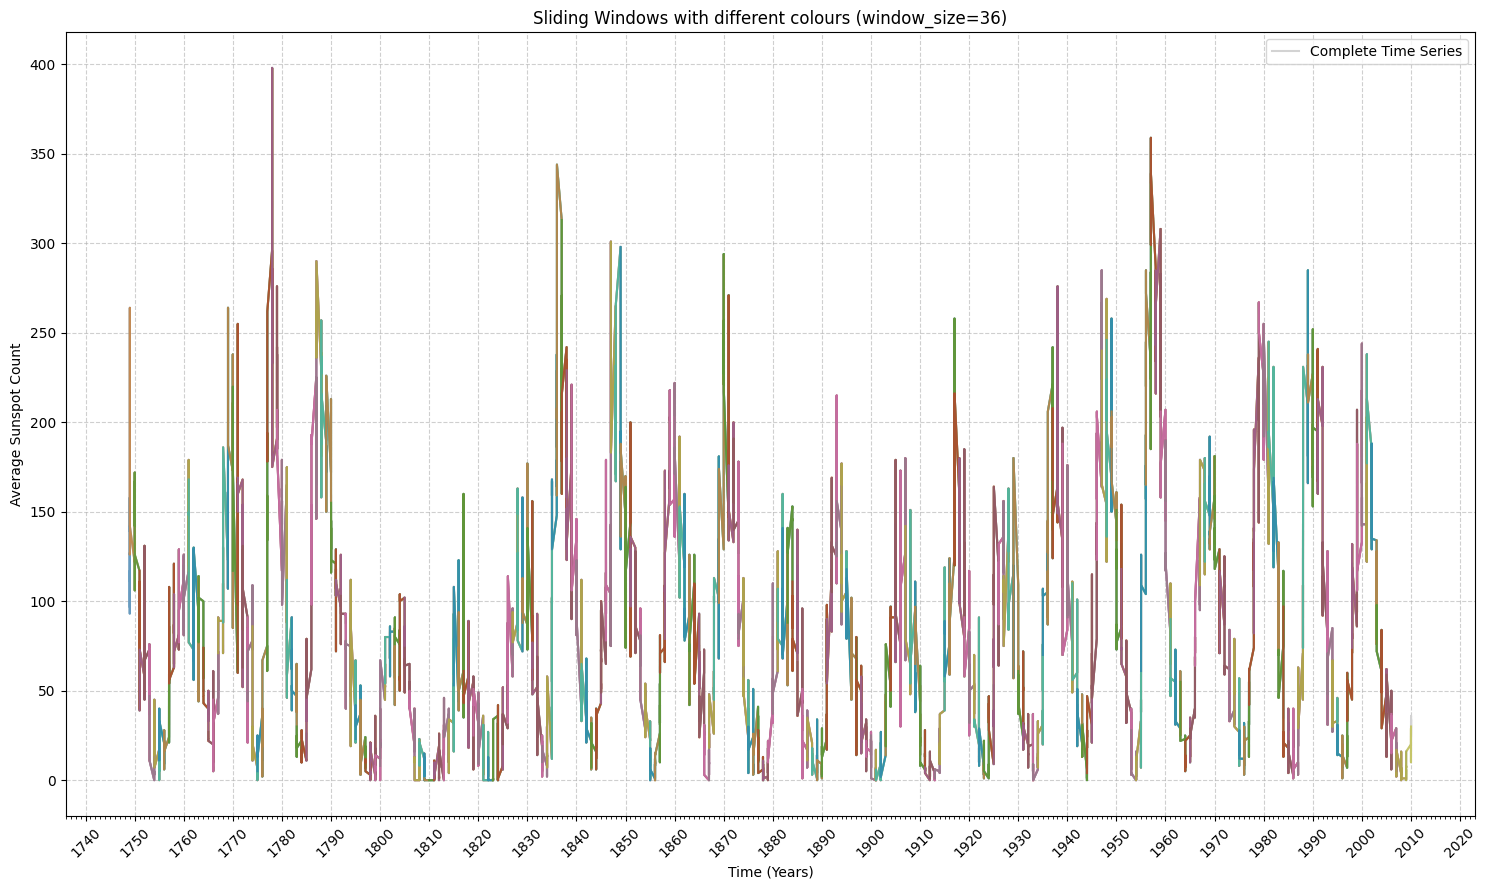

In [8]:
def plot_sliding_windows(series, time, window_size, step=1):
    plt.figure(figsize=(15, 9))
    plt.title(f"Sliding Windows with different colours (window_size={window_size})")

    # Background full series
    plt.plot(time, series, color="lightgrey", label="Complete Time Series")

    # Sliding windows
    for start in range(0, len(series) - window_size, step):
        end = start + window_size
        plt.plot(time[start:end], series[start:end], alpha=0.6)

    # Axis labels
    plt.xlabel("Time (Years)")
    plt.ylabel("Average Sunspot Count")

    # Format x-axis as years
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator(base=10))   # Major ticks every 10 years
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.YearLocator())          # Minor ticks every year

    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage (make sure `time_step` is datetime index/Series)
plot_sliding_windows(sunspots, time_step, window_size=36, step=8)

Inference: The time series shows cyclical/seasonal structure (11 years).
It is not stationary, needs differencing + seasonal differencing.
Candidate model: SARIMA(1,1,0)(1,1,0,132).
 We use a window size of 36 to create the sequences for our models.

# Checking for the Stationarity

## ADF Test

In [12]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF Test
def adf_test(series, signif=0.05):
    result = adfuller(series, autolag='AIC')
    stat, p_value, used_lag, n_obs, crit_values, icbest = result
    
    print("=== Augmented Dickey-Fuller Test ===")
    print(f"ADF Statistic: {stat}")
    print(f"p-value: {p_value}")
    print(f"Used lags: {used_lag}")
    print(f"Number of observations: {n_obs}")
    print("Critical Values:")
    for key, value in crit_values.items():
        print(f"   {key}: {value}")
    
    if p_value < signif:
        print(" Result: Reject null hypothesis (stationary)")
    else:
        print(" Result: Fail to reject null hypothesis (non-stationary)")

print("ADF Test on Training Data:")
adf_test(sunspots)

ADF Test on Training Data:
=== Augmented Dickey-Fuller Test ===
ADF Statistic: -10.39030858991284
p-value: 2.029076801912227e-18
Used lags: 28
Number of observations: 3115
Critical Values:
   1%: -3.43245102630828
   5%: -2.862468302843017
   10%: -2.5672641578701927
 Result: Reject null hypothesis (stationary)


Inference: If we consider the ADF test result, the p-value is very small (2.029076801912227e-18), which is far below the common significance levels (0.01, 0.05, 0.10). This suggests that we can reject the null hypothesis of the ADF test, indicating that the series is stationary.


## KPSS Test

In [15]:
# KPSS Test
def kpss_test(series, signif=0.05):
    result = kpss(series, regression='c', nlags="auto")
    stat, p_value, lags, crit_values = result
    
    print("\n=== KPSS Test ===")
    print(f"KPSS Statistic: {stat}")
    print(f"p-value: {p_value}")
    print(f"Lags used: {lags}")
    print("Critical Values:")
    for key, value in crit_values.items():
        print(f"   {key}: {value}")
    
    if p_value < signif:
        print(" Result: Reject null hypothesis (non-stationary)")
    else:
        print(" Result: Fail to reject null hypothesis (stationary)")

print("\nKPSS Test on Training Data:")
kpss_test(sunspots)


KPSS Test on Training Data:

=== KPSS Test ===
KPSS Statistic: 0.1597001765772278
p-value: 0.1
Lags used: 32
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739
 Result: Fail to reject null hypothesis (stationary)


Inference: For the KPSS test, the p-value is 0.1, suggesting that we fail to reject the null hypothesis. This also indicates that the series is stationary.

## Testing with Arima Model

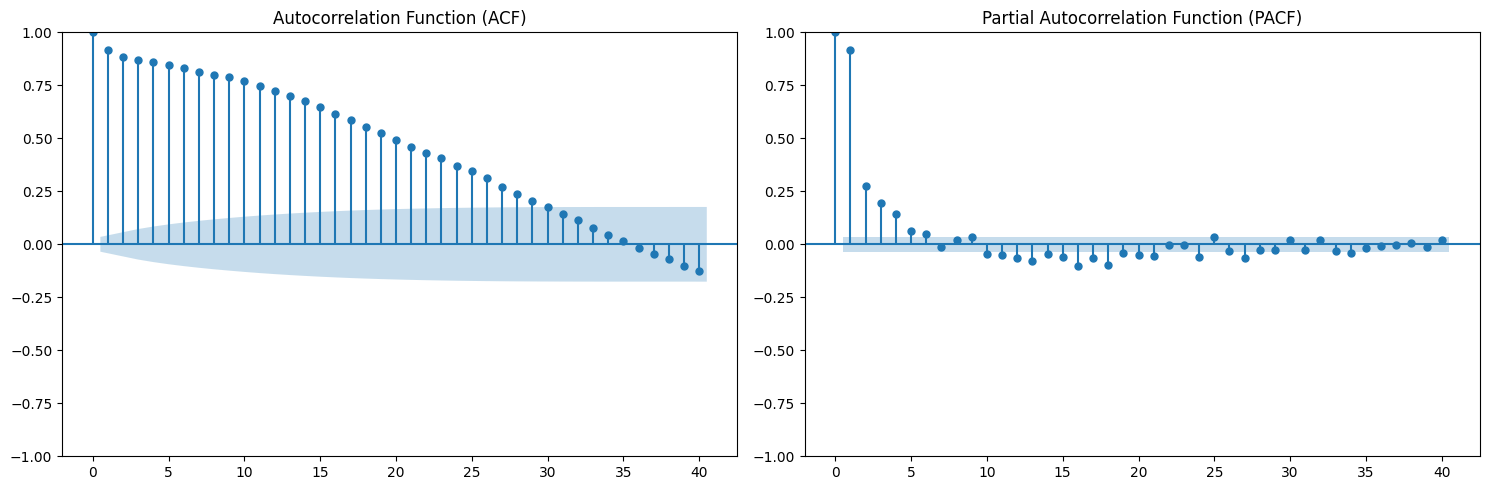

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Number of months to forecast
n_steps = len(test_df)


# Step 1: Plot ACF and PACF (from train data)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(sunspots, ax=axes[0], lags=40)
axes[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(sunspots, ax=axes[1], lags=40, method='ywm')
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

Inference:
The series looks autoregressive (AR) in nature, with order ~ 1.
Since ACF tails off and PACF cuts off at lag 1 -> AR(1) is a good starting model.

In [19]:
# Step 1: Auto ARIMA order selection ===
auto_model = auto_arima(
    sunspots, 
    seasonal=False,      # set True if you want SARIMA
    stepwise=True,
    suppress_warnings=True,
    trace=True           # shows tried orders
)
print("Best ARIMA order:", auto_model.order)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=29281.537, Time=0.70 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=38340.130, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=29777.294, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=35246.882, Time=0.44 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=29279.536, Time=0.23 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=33472.973, Time=0.52 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=29325.949, Time=0.24 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=29281.536, Time=0.35 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=32524.249, Time=0.65 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=29284.002, Time=0.50 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=29281.522, Time=1.11 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=29263.998, Time=0.96 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=31802.194, Time=1.01 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=29306.120, Time=0.67 sec
 ARIMA(2,0,2)(0,0,0

In [20]:
# Step 2: Fit ARIMA with best order ===
arma_model = ARIMA(sunspots, order=auto_model.order).fit()
print(arma_model.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3144
Model:                 ARIMA(1, 0, 2)   Log Likelihood              -14627.000
Date:                Fri, 22 Aug 2025   AIC                          29264.001
Time:                        03:33:37   BIC                          29294.267
Sample:                             0   HQIC                         29274.861
                               - 3144                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         82.9934     15.908      5.217      0.000      51.815     114.172
ar.L1          0.9825      0.004    271.374      0.000       0.975       0.990
ma.L1         -0.4071      0.014    -28.940      0.0

In [21]:
# === Step 4: Forecast ===
forecast_res = arma_model.get_forecast(steps=n_steps)
forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

In [22]:
# Handle both cases safely
if isinstance(forecast_ci, np.ndarray):
    lower_bound = forecast_ci[:, 0]
    upper_bound = forecast_ci[:, 1]
else:
    lower_bound = forecast_ci.iloc[:, 0].to_numpy()
    upper_bound = forecast_ci.iloc[:, 1].to_numpy()

# Assign to test_df
test_df["Forecasted_Sunspots"] = (
    forecast_mean if isinstance(forecast_mean, np.ndarray) else forecast_mean.to_numpy()
)
test_df["Lower_CI"] = lower_bound
test_df["Upper_CI"] = upper_bound

print(test_df.head())

       Month  Forecasted_Sunspots   Lower_CI    Upper_CI
0 2011-01-01            29.816635 -19.902062   79.535331
1 2011-01-02            31.827711 -25.534072   89.189493
2 2011-01-03            32.720633 -28.874011   94.315276
3 2011-01-04            33.597971 -31.823774   99.019717
4 2011-01-05            34.459999 -34.455100  103.375099


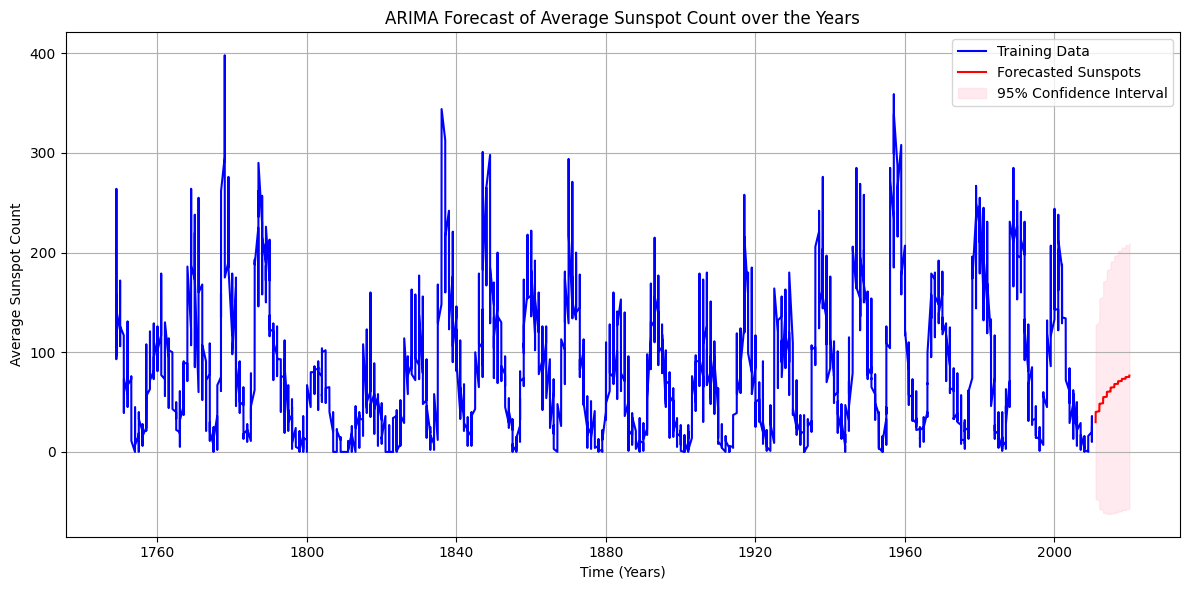

In [23]:
# Reset index for plotting
train_plot = train_df.reset_index()
test_plot = test_df.reset_index()

plt.figure(figsize=(12,6))

# Training data
plt.plot(train_plot["Month"], train_plot["Avg_sunspot_count"], 
         label="Training Data", color="blue")

# Forecasted values
plt.plot(test_plot["Month"], test_plot["Forecasted_Sunspots"], 
         color="red", label="Forecasted Sunspots")

# Confidence interval shading
plt.fill_between(
    test_plot["Month"], 
    test_plot["Lower_CI"], 
    test_plot["Upper_CI"], 
    color="pink", alpha=0.3, 
    label="95% Confidence Interval"
)

plt.title("ARIMA Forecast of Average Sunspot Count over the Years")
plt.xlabel("Time (Years)")
plt.ylabel("Average Sunspot Count")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Inference: ARIMA model does not work well in our case. Since we have clear seasonal patterns, it would be definitely better if we try SARIMA instead of ARIMA.

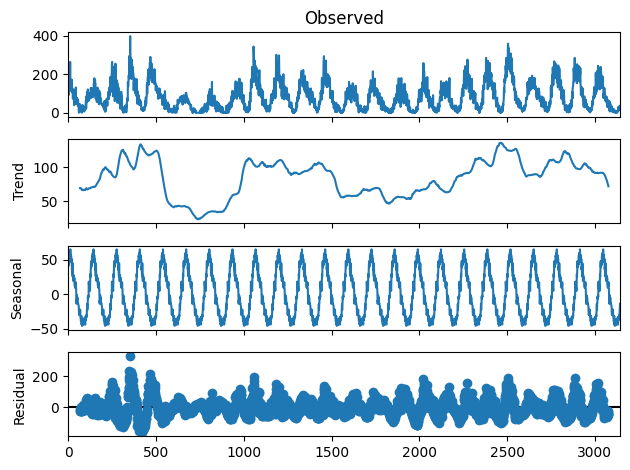

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Step 1: Seasonal Decomposition

result = seasonal_decompose(sunspots, model='additive', period=132)  # ~11-year cycle
result.plot()
plt.show()

Inference: The sunspot data shows a strong cyclical seasonal component with an underlying long-term trend, characteristic of solar cycles. While the trend and seasonality explain much of the variation, there remain irregular residual fluctuations, suggesting the need for hybrid models (like SARIMA+LSTM) to better capture non-linear dynamics.

In [26]:
# Step 2: Develop Fourier features
def make_fourier(n, period=132, K=3, start=0, dtype=np.float32):
    t = np.arange(start, start+n, dtype=dtype)
    cols = []
    for k in range(1, K+1):
        cols.append(np.sin(2*np.pi*k*t/period))
        cols.append(np.cos(2*np.pi*k*t/period))
    return np.column_stack(cols).astype(dtype)

K = 5  # richer Fourier basis
n_train = len(y)
n_test  = len(test_df)

X_fourier = make_fourier(n_train, period=132, K=K, start=0)
X_test_future = make_fourier(n_test, period=132, K=K, start=n_train)# ------------------ Fourier features ------------------
def make_fourier(n, period=132, K=3, start=0, dtype=np.float32):
    t = np.arange(start, start+n, dtype=dtype)
    cols = []
    for k in range(1, K+1):
        cols.append(np.sin(2*np.pi*k*t/period))
        cols.append(np.cos(2*np.pi*k*t/period))
    return np.column_stack(cols).astype(dtype)

K = 5  # richer Fourier basis
n_train = len(y)
n_test  = len(test_df)

X_fourier = make_fourier(n_train, period=132, K=K, start=0)
X_test_future = make_fourier(n_test, period=132, K=K, start=n_train)

## Testing with Hybrid SARIMA Model + LSTM

In [28]:
# Step 3: Using Auto-SARIMA Model
auto_model = pm.auto_arima(
    y=y,
    exogenous=X_fourier,
    seasonal=False,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    stepwise=True,
    suppress_warnings=True,
    maxiter=500
)

sarima_fitted = auto_model.predict_in_sample(exogenous=X_fourier)
residuals = y - sarima_fitted

In [29]:
# Step 4: Prepare residuals for LSTM 
window_size = 36
features = np.hstack([residuals.reshape(-1,1), X_fourier])
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window, :])
        y.append(data[i+window, 0])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(features_scaled, window_size)

split = -120
X_train, X_val = X_seq[:split], X_seq[split:]
y_train, y_val = y_seq[:split], y_seq[split:]

model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(window_size, X_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=40, batch_size=32, verbose=0)

In [30]:
# Step 5: Forecast residuals
features_scaled_full = scaler.transform(features)
seq_input = features_scaled_full[-window_size:].tolist()

resid_preds = []
for i in range(n_test):
    future_row = np.zeros((1, features_scaled_full.shape[1]))
    future_row[0,1:] = X_test_future[i]
    seq_array = np.array(seq_input[-window_size:]).reshape(1, window_size, -1)
    pred_scaled = model.predict(seq_array, verbose=0)
    resid_preds.append(pred_scaled[0,0])
    new_entry = future_row
    new_entry[0,0] = pred_scaled[0,0]
    seq_input.append(new_entry[0])

resid_preds = np.array(resid_preds).reshape(-1,1)
dummy_fourier = X_test_future
inv_scaled = scaler.inverse_transform(np.hstack([resid_preds, dummy_fourier]))
lstm_resid_forecast = inv_scaled[:,0]


In [31]:
# Step 6: Hybrid forecast
sarima_forecast = auto_model.predict(n_periods=n_test, exogenous=X_test_future)
hybrid_forecast = sarima_forecast + lstm_resid_forecast


In [32]:
#------------- Final Submission --------------------
submission_df = pd.DataFrame({
    "Month": month_col,                
    "Avg_sunspot_count": hybrid_forecast.astype(int)
})

submission_df["Avg_sunspot_count"] = submission_df["Avg_sunspot_count"].clip(lower=0)

submission_df.to_csv("submission.csv", index=False)
print(submission_df.head())


        Month  Avg_sunspot_count
0  01-01-2011                 37
1  02-01-2011                 44
2  03-01-2011                 49
3  04-01-2011                 53
4  05-01-2011                 57


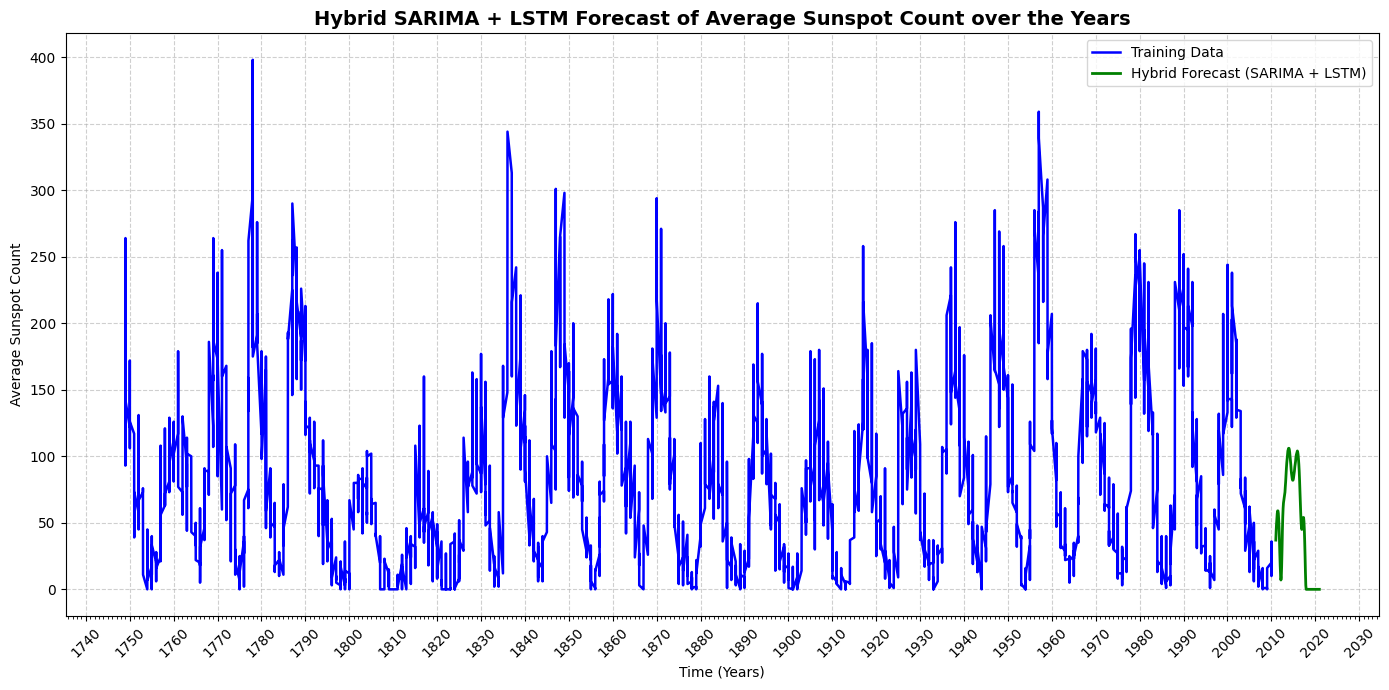

In [33]:
# If Month is the index, reset it
if train_df.index.name == "Month":
    train_df = train_df.reset_index()

if submission_df.index.name == "Month":
    submission_df = submission_df.reset_index()
    
# Ensure datetime format
train_df['Month'] = pd.to_datetime(train_df['Month'], errors='coerce')
submission_df['Month'] = pd.to_datetime(submission_df['Month'], errors='coerce')

plt.figure(figsize=(14,7))

# --- Training data ---
plt.plot(train_df['Month'], train_df['Avg_sunspot_count'], 
         label="Training Data", color="blue", linewidth=1.8)

# --- Hybrid forecast (SARIMA + LSTM) ---
plt.plot(submission_df['Month'], submission_df['Avg_sunspot_count'], 
         color="green", linewidth=2, label="Hybrid Forecast (SARIMA + LSTM)")

# Titles & labels
plt.title("Hybrid SARIMA + LSTM Forecast of Average Sunspot Count over the Years", fontsize=14, weight="bold")
plt.xlabel("Time (Years)")
plt.ylabel("Average Sunspot Count")

# --- Clean up x-axis like pic 1 ---
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=10))   # tick every 10 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(base=1))    # minor ticks every year

plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Inference: Based on the Forecast, we can confirm that Auto Sarim + LSTM is better fit to predict the sunspot values. It tries to predict and capture the Seasonality and trend.